C:\Users\Mattis\AppData\Local\Temp\ipykernel_24708\981182605.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)


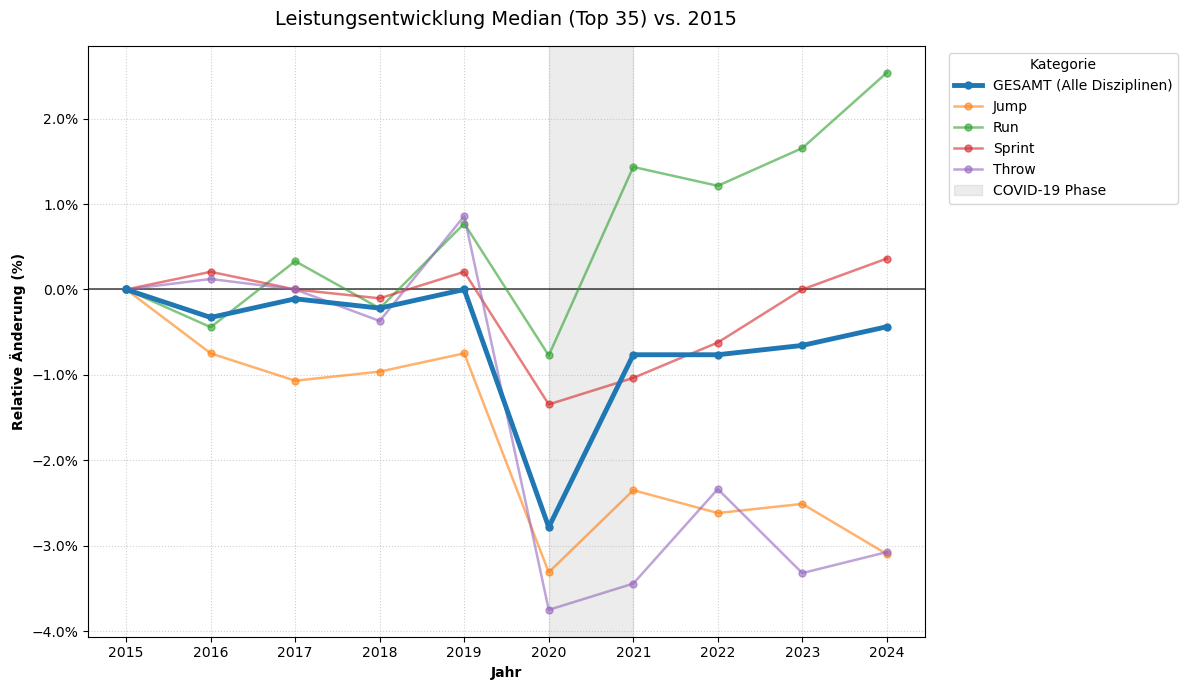

In [9]:
import sys
import os
import pandas as pd
import matplotlib.ticker as mtick
import numpy as np
import matplotlib.pyplot as plt

n_ = 35
# --- 1. PROJEKT-SETUP (Zentrales Laden laut Readme) ---
# Wir gehen davon aus, dass dieses Skript in einem Unterordner (z.B. erik/) liegt
sys.path.append(os.path.abspath("..")) 

import util

# --- 2. DATEN LADEN ÜBER UTIL ---
# util.load_data() findet die CSV im Ordner data_csv/ automatisch
df = util.load_data()

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

n_ = 35

df = df[df['jahr'] >= 2015].copy()
# --- 3. BERECHNUNG ---

# 1. Mittelwert pro Disziplingruppe (Jump, Run, etc.)
# WICHTIG: Wir nennen die Spalte hier direkt 'iaaf_score_mean'
category_stats = df.groupby(['jahr', 'group'])['iaaf_score'].median().reset_index(name='iaaf_score_mean')
category_stats.rename(columns={'group': 'category'}, inplace=True)

# 2. Gesamtdurchschnitt über alle Disziplinen
total_stats = df.groupby(['jahr'])['iaaf_score'].median().reset_index(name='iaaf_score_mean')
total_stats['category'] = 'GESAMT (Alle Disziplinen)'

# 3. Zusammenführen
final_stats = pd.concat([category_stats, total_stats], ignore_index=True)

# 4. Relative Änderung zu 2015 berechnen
def calculate_pct_change(group):
    # Wir suchen den Wert von 2015 für diese spezifische Gruppe
    base_val = group.loc[group['jahr'] == 2015, 'iaaf_score_mean']
    if not base_val.empty:
        b = base_val.values[0]
        group['rel_change_pct'] = ((group['iaaf_score_mean'] - b) / b) * 100
    else:
        group['rel_change_pct'] = np.nan # Falls 2015 nicht existiert
    return group

# Sicherstellen, dass nach 'category' gruppiert wird
final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

# --- 4. PLOTTING ---

fig, ax = plt.subplots(figsize=(12, 7))

for cat in sorted(final_stats['category'].unique()):
    cat_data = final_stats[final_stats['category'] == cat].sort_values('jahr')
    
    is_gesamt = 'GESAMT' in cat
    lw = 3.5 if is_gesamt else 1.8
    alpha = 1.0 if is_gesamt else 0.6
    
    ax.plot(cat_data['jahr'], cat_data['rel_change_pct'], 
            label=cat,
            linewidth=lw, 
            alpha=alpha,
            zorder=10 if is_gesamt else 5, 
            marker='o', markersize=5)

# Styling
ax.axhline(0, color='black', linewidth=1.2, alpha=0.7)
ax.axvspan(2020, 2021, color='grey', alpha=0.15, label='COVID-19 Phase')

ax.xaxis.set_major_locator(mtick.MultipleLocator(1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_title(f'Leistungsentwicklung Median (Top {n_}) vs. 2015', fontsize=14, pad=15)
ax.set_ylabel('Relative Änderung (%)', fontweight='bold')
ax.set_xlabel('Jahr', fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)

# Legende
ax.legend(title='Kategorie', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import bootstrap, iqr

df_recent = df
# 1. Funktion für die Effektgröße: Relative Änderung des IQR
def calculate_relative_diff(sample_2020, sample_baseline):
    # Vergleicht das Median-Niveau
    m_2020 = np.median(sample_2020)
    m_base = np.median(sample_baseline)
    if m_base == 0: return 0
    return (m_2020 / m_base) - 1

bootstrap_effects = []
categories_to_test = sorted(df_recent['group'].unique().tolist()) + ['GESAMT (Alle Disziplinen)']

for cat in categories_to_test:
    if 'GESAMT' in cat:
        d_2020 = df_recent[df_recent['jahr'] == 2020]['iaaf_score'].values
        d_base = df_recent[df_recent['jahr'] != 2020]['iaaf_score'].values
    else:
        d_2020 = df_recent[(df_recent['group'] == cat) & (df_recent['jahr'] == 2020)]['iaaf_score'].values
        d_base = df_recent[(df_recent['group'] == cat) & (df_recent['jahr'] != 2020)]['iaaf_score'].values

    if len(d_2020) > 15 and len(d_base) > 15:
        res = bootstrap((d_2020, d_base), calculate_relative_diff, 
                        n_resamples=5000, 
                        confidence_level=0.95, 
                        method='percentile')
        
        ci = res.confidence_interval
        observed_effect = calculate_relative_diff(d_2020, d_base) * 100
        ci_low = ci.low * 100
        ci_high = ci.high * 100
        
        # --- NEU: Signifikanz-Check ---
        # Ein Effekt ist signifikant, wenn das Intervall NICHT die Null enthält
        is_significant = not (ci_low <= 0 <= ci_high)
        
        bootstrap_effects.append({
            'Kategorie': cat,
            'Effektgröße (%)': round(observed_effect, 1),
            '95% KI unten (%)': round(ci_low, 1),
            '95% KI oben (%)': round(ci_high, 1),
            'Signifikant': "✅ JA" if is_significant else "❌ Nein",
            'Trend': "Zunahme Streuung" if observed_effect > 0 else "Abnahme Streuung"
        })

# Ergebnis-Tabelle
df_effects = pd.DataFrame(bootstrap_effects)

# Sortierung nach Stärke des Effekts
display(df_effects.sort_values('Effektgröße (%)', ascending=False))

,Kategorie,Effektgröße (%),95% KI unten (%),95% KI oben (%),Signifikant,Trend
2,Sprint,-1.1,-1.7,-0.8,✅ JA,Abnahme Streuung
1,Run,-1.5,-2.5,-0.8,✅ JA,Abnahme Streuung
0,Jump,-1.7,-2.7,-0.9,✅ JA,Abnahme Streuung
4,GESAMT (Alle Disziplinen),-2.5,-2.7,-1.9,✅ JA,Abnahme Streuung
3,Throw,-2.6,-3.2,-1.1,✅ JA,Abnahme Streuung


In [14]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

# 1. Daten in Blöcke unterteilen
df_baseline = df_recent[(df_recent['jahr'] >= 2015) & (df_recent['jahr'] <= 2019)]
df_2020 = df_recent[df_recent['jahr'] == 2020]

comparison_results = []
categories = sorted(df_recent['group'].unique().tolist()) + ['GESAMT']

for cat in categories:
    # Daten für die jeweilige Kategorie extrahieren
    if cat == 'GESAMT':
        data_base = df_baseline['iaaf_score'].values
        data_2020 = df_2020['iaaf_score'].values
    else:
        data_base = df_baseline[df_baseline['group'] == cat]['iaaf_score'].values
        data_2020 = df_2020[df_2020['group'] == cat]['iaaf_score'].values
    
    if len(data_2020) > 0 and len(data_base) > 0:
        # MWU-Test
        stat, p_val = mannwhitneyu(data_2020, data_base, alternative='two-sided')
        
        # Mediane für die Interpretation
        med_base = np.median(data_base)
        med_2020 = np.median(data_2020)
        rel_diff = (med_2020 / med_base - 1) * 100
        
        comparison_results.append({
            'Kategorie': cat,
            'Median 2015-19': round(med_base, 1),
            'Median 2020': round(med_2020, 1),
            'Diff (%)': round(rel_diff, 2),
            'p-Value': round(p_val, 4),
            'Signifikant': "✅ JA" if p_val < 0.05 else "❌ Nein"
        })

df_final_test = pd.DataFrame(comparison_results)
display(df_final_test.sort_values('Diff (%)'))

,Kategorie,Median 2015-19,Median 2020,Diff (%),p-Value,Signifikant
3,Throw,815.0,782.5,-3.99,0.0,✅ JA
0,Jump,929.0,905.0,-2.58,0.0,✅ JA
4,GESAMT,914.0,890.5,-2.57,0.0,✅ JA
2,Sprint,966.0,953.0,-1.35,0.0,✅ JA
1,Run,907.0,899.0,-0.88,0.0,✅ JA


In [16]:
import numpy as np
import pandas as pd
from scipy.stats import bootstrap, iqr

# 1. Daten vorbereiten
df_base = df_recent[(df_recent['jahr'] >= 2015) & (df_recent['jahr'] <= 2019)]
df_2020 = df_recent[df_recent['jahr'] == 2020]

# 2. Funktion für die Effektgröße (Relative Änderung des IQR)
def iqr_diff_ratio(sample_2020, sample_baseline):
    iqr_2020 = iqr(sample_2020)
    iqr_base = iqr(sample_baseline)
    if iqr_base == 0: return 0
    return (iqr_2020 / iqr_base) - 1

results_boot = []
categories = sorted(df_recent['group'].unique().tolist()) + ['GESAMT']

print("Running Bootstrap (5000 resamples)...")

for cat in categories:
    if cat == 'GESAMT':
        d_base = df_base['iaaf_score'].values
        d_2020 = df_2020['iaaf_score'].values
    else:
        d_base = df_base[df_base['group'] == cat]['iaaf_score'].values
        d_2020 = df_2020[df_2020['group'] == cat]['iaaf_score'].values

    if len(d_2020) > 15 and len(d_base) > 15:
        # Bootstrap berechnet das KI für die Differenz der IQRs
        res = bootstrap((d_2020, d_base), iqr_diff_ratio, 
                        n_resamples=5000, 
                        confidence_level=0.95, 
                        method='percentile')
        
        ci = res.confidence_interval
        observed = iqr_diff_ratio(d_2020, d_base) * 100
        
        # Signifikanz: Enthält das KI die Null?
        is_sig = not (ci.low <= 0 <= ci.high)
        
        results_boot.append({
            'Kategorie': cat,
            'IQR Änderung (%)': round(observed, 2),
            '95% KI unten': round(ci.low * 100, 2),
            '95% KI oben': round(ci.high * 100, 2),
            'Signifikant': "✅ JA" if is_sig else "❌ Nein"
        })

df_boot_iqr = pd.DataFrame(results_boot)
display(df_boot_iqr.sort_values('IQR Änderung (%)', ascending=False))

Running Bootstrap (5000 resamples)...


,Kategorie,IQR Änderung (%),95% KI unten,95% KI oben,Signifikant
2,Sprint,12.93,3.42,20.00,✅ JA
1,Run,6.41,0.65,13.82,✅ JA
4,GESAMT,5.00,1.25,8.91,✅ JA
3,Throw,-0.18,-6.99,9.42,❌ Nein
0,Jump,-6.79,-11.85,4.58,❌ Nein


In [17]:
# 1. Daten vorbereiten: Baseline vs. Erholungsphase
df_base = df_recent[(df_recent['jahr'] >= 2015) & (df_recent['jahr'] <= 2019)]
df_post = df_recent[(df_recent['jahr'] >= 2021) & (df_recent['jahr'] <= 2024)]

results_boot = []
categories = sorted(df_recent['group'].unique().tolist()) + ['GESAMT']

print("Running Bootstrap: Baseline (15-19) vs. Post-Corona (21-24)...")

for cat in categories:
    if cat == 'GESAMT':
        d_base = df_base['iaaf_score'].values
        d_post = df_post['iaaf_score'].values
    else:
        d_base = df_base[df_base['group'] == cat]['iaaf_score'].values
        d_post = df_post[df_post['group'] == cat]['iaaf_score'].values

    if len(d_post) > 15 and len(d_base) > 15:
        # Resampling für den Vergleich der Streuung
        res = bootstrap((d_post, d_base), iqr_diff_ratio, 
                        n_resamples=5000, 
                        confidence_level=0.95, 
                        method='percentile')
        
        ci = res.confidence_interval
        observed = iqr_diff_ratio(d_post, d_base) * 100
        is_sig = not (ci.low <= 0 <= ci.high)
        
        results_boot.append({
            'Kategorie': cat,
            'N (Post)': len(d_post),
            'IQR Änderung (%)': round(observed, 2),
            '95% KI unten': round(ci.low * 100, 2),
            '95% KI oben': round(ci.high * 100, 2),
            'Signifikant': "✅ JA" if is_sig else "❌ Nein"
        })

df_boot_post = pd.DataFrame(results_boot)
display(df_boot_post.sort_values('IQR Änderung (%)', ascending=False))

Running Bootstrap: Baseline (15-19) vs. Post-Corona (21-24)...


,Kategorie,N (Post),IQR Änderung (%),95% KI unten,95% KI oben,Signifikant
4,GESAMT,28543,9.38,6.79,11.39,✅ JA
3,Throw,6297,6.19,2.07,12.86,✅ JA
1,Run,7800,5.77,2.55,9.34,✅ JA
2,Sprint,7889,3.45,0.00,7.08,❌ Nein
0,Jump,6557,-3.85,-7.86,2.29,❌ Nein
